In [31]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/my_image_classifier.keras")
print("Model loaded successfully!")

Model loaded successfully!


In [30]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [32]:
from tensorflow.keras.models import load_model

loaded_model = load_model("/content/drive/MyDrive/my_image_classifier.keras")
print("Model loaded successfully!")

Model loaded successfully!


In [74]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model

# Reload dataset
dataset_path = "/content/drive/MyDrive/ImageDataset"
img_height = 180
img_width = 180
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = val_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Reload model
loaded_model = load_model("/content/drive/MyDrive/my_image_classifier.keras")
print("Model loaded!")

# Part 2: Get predictions
y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    predictions = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Done! Shapes:")
print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
print("y_prob:", y_prob.shape)

Found 5817 files belonging to 20 classes.
Using 4654 files for training.
Found 5817 files belonging to 20 classes.
Using 1163 files for validation.
Model loaded!
Done! Shapes:
y_true: (1163,)
y_pred: (1163,)
y_prob: (1163, 20)


In [34]:
from sklearn.metrics import classification_report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

               precision    recall  f1-score   support

    anthurium       0.96      0.96      0.96        51
bougainvillea       0.82      0.89      0.85        53
chrysanthemum       0.63      0.94      0.76        51
       cosmos       0.85      0.63      0.72        46
        daisy       0.70      0.67      0.69        55
     geranium       0.84      0.87      0.86        62
     hibiscus       0.84      0.74      0.79        65
        ixora       0.80      0.62      0.70        52
      jasmine       0.75      0.95      0.84        62
         lily       0.72      0.76      0.74        50
        lotus       0.94      0.86      0.90        57
     marigold       0.87      0.80      0.83        65
       orchid       0.66      0.92      0.77        79
        peony       0.81      0.80      0.80        64
      petunia       0.75      0.89      0.82        55
        poppy       0.72      0.54      0.62        48
         rose       0.88      0.70      

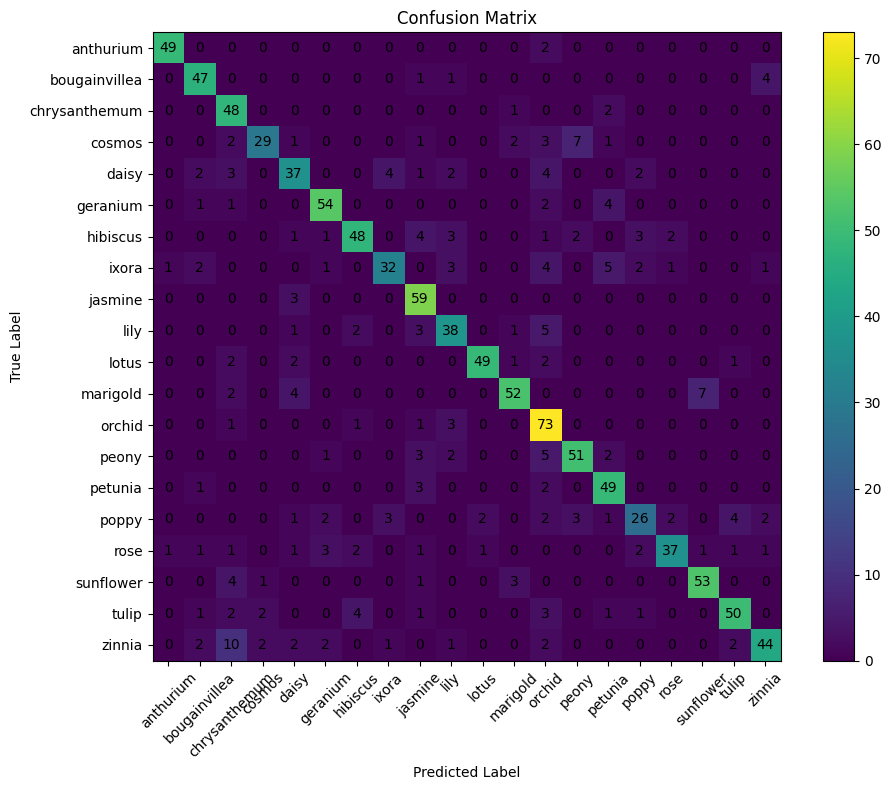

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
# Annotate values
for i in range(len(class_names)):
  for j in range(len(class_names)):
    plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
# Binarize labels
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=range(n_classes))
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])

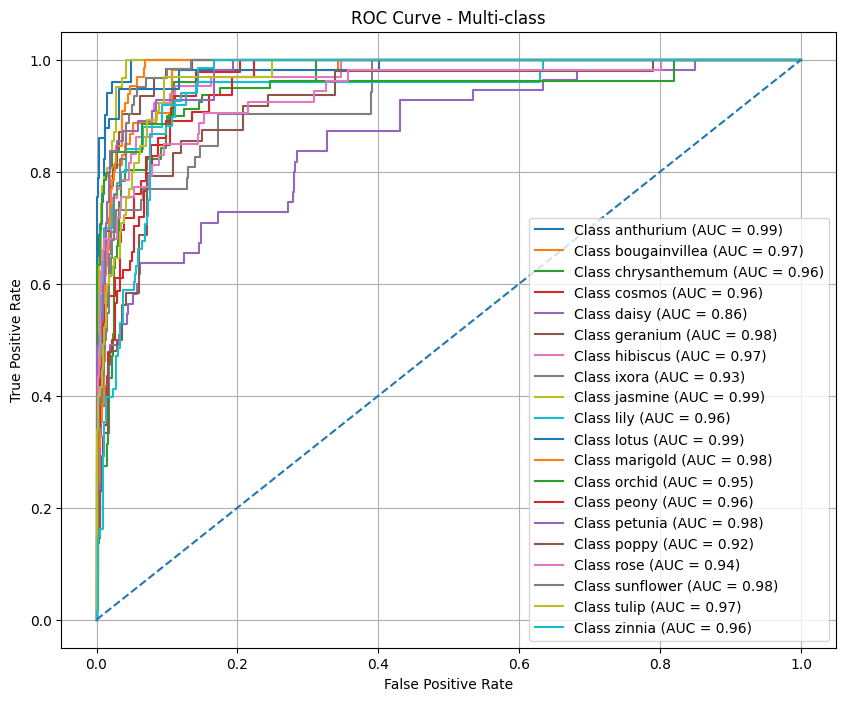

In [37]:
plt.figure(figsize=(10, 8))
for i in range(n_classes):
  plt.plot(fpr[i], tpr[i], label=f"Class {class_names[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--") # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-class")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [38]:
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
print("Overall AUC Score:", auc_score)

Overall AUC Score: 0.9606667251228428


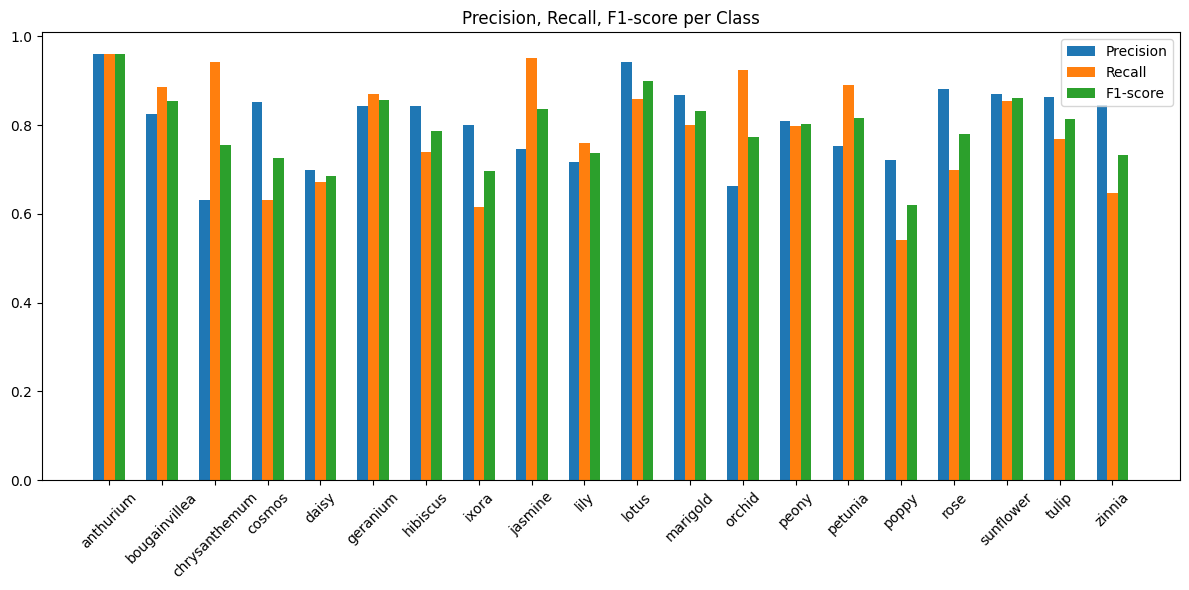

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)
x = np.arange(len(class_names))
plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, precision, width=0.2, label='Precision')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x + 0.2, f1, width=0.2, label='F1-score')
plt.xticks(x, class_names, rotation=45)
plt.title("Precision, Recall, F1-score per Class")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/my_image_classifier.keras")
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (32, 180, 180, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (32, 180, 180, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 180, 180, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 90, 90, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 90, 90, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 45, 45, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 45, 45, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 22, 22, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 22, 22, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (32, 30976)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 128)              │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 20)               │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,973,662 (45.68 MB)

 Trainable params: 3,991,220 (15.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,982,442 (30.45 MB)

In [41]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
img_path = "/content/drive/MyDrive/ImageDataset/test.jpg"
img = load_img(img_path, target_size=(180, 180))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [75]:
  for layer in model.layers:
    print(layer.name)

sequential
rescaling_1
conv2d_3
batch_normalization_3
max_pooling2d_3
conv2d_4
batch_normalization_4
max_pooling2d_4
conv2d_5
batch_normalization_5
max_pooling2d_5
dropout_2
flatten_2
dense_2
dropout_3
dense_3


In [43]:
last_conv_layer_name = "conv2d_8" # Adjust based on your model

In [44]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img_path = "/content/drive/MyDrive/ImageDataset/test.jpg"
img = load_img(img_path, target_size=(180, 180))
img_array = img_to_array(img)
img_array_expanded = np.expand_dims(img_array, axis=0) / 255.0
print("Image loaded! Shape:", img_array_expanded.shape)

Image loaded! Shape: (1, 180, 180, 3)


In [53]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img_path = "/content/drive/MyDrive/ImageDataset/test.jpg"
img = load_img(img_path, target_size=(180, 180))
img_array = img_to_array(img)
img_array_expanded = np.expand_dims(img_array, axis=0) / 255.0
print("Image loaded! Shape:", img_array_expanded.shape)

Image loaded! Shape: (1, 180, 180, 3)


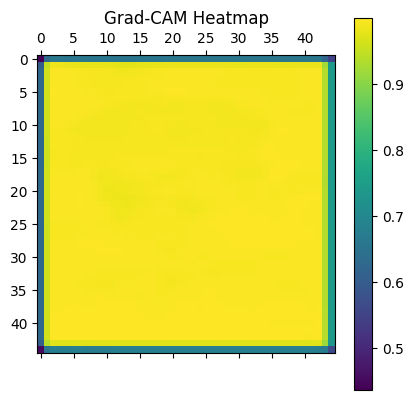

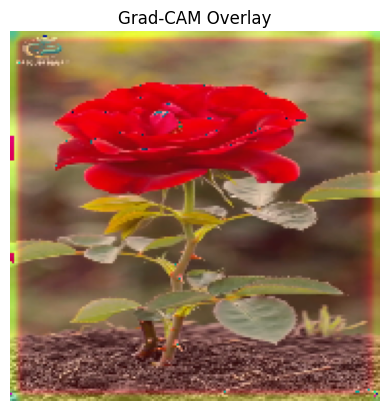

In [61]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    img_tensor = tf.cast(img_array, tf.float32)

    # Run through layers and capture conv output
    x = img_tensor
    conv_output = None

    with tf.GradientTape() as tape:
        for layer in model.layers:
            x = layer(x, training=False)
            if layer.name == last_conv_layer_name:
                conv_output = x
                tape.watch(conv_output)

        predictions = x
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Part 5
heatmap = get_gradcam_heatmap(loaded_model, img_array_expanded, "conv2d_8")
plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

# Part 6
img_bgr = cv2.imread(img_path)
img_bgr = cv2.resize(img_bgr, (180, 180))
heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_resized = cv2.resize(heatmap_uint8, (img_bgr.shape[1], img_bgr.shape[0]))
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
superimposed_img = heatmap_colored * 0.4 + img_bgr
plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis('off')
plt.show()

In [62]:
import tensorflow as tf
import numpy as np
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
  grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer_name).output, model.output]
  )
  with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    if pred_index is None:
      pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]
  grads = tape.gradient(class_channel, conv_outputs)
  pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
  conv_outputs = conv_outputs[0]
  heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap)
  heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
  return heatmap.numpy()

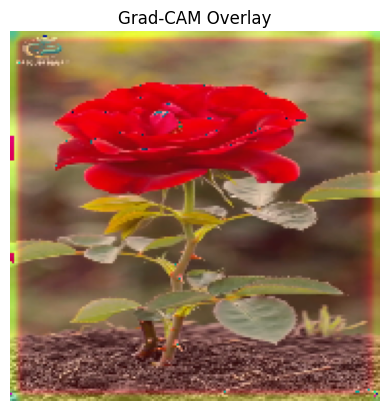

In [63]:
import cv2
img = cv2.imread(img_path)
img = cv2.resize(img, (180, 180))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = heatmap * 0.4 + img
plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis('off')
plt.show()

In [64]:
from tensorflow.keras import layers
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2),
])

In [66]:
from tensorflow.keras import models, layers
model = models.Sequential([
  data_augmentation,
  layers.Rescaling(1./255, input_shape=(180, 180, 3)),
  layers.Conv2D(32, 3, activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),
  layers.Dropout(0.4),
  layers.Flatten(),
  layers.Dense(256, activation='relu'),
  layers.Dropout(0.5),
  layers.Dense(len(class_names))
  ])

In [71]:
from tensorflow.keras.optimizers import Adam
model.compile(
  optimizer=Adam(learning_rate=0.0001),
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy']
)

In [70]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
  monitor='val_loss',
  patience=3,
  restore_best_weights=True
)

In [76]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=20,
  callbacks=[early_stop]
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 897s 6s/step - accuracy: 0.1429 - loss: 3.2054 - val_accuracy: 0.0396 - val_loss: 9.1902
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 710s 5s/step - accuracy: 0.1689 - loss: 2.7925 - val_accuracy: 0.0490 - val_loss: 8.5466
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 692s 5s/step - accuracy: 0.1876 - loss: 2.7083 - val_accuracy: 0.1952 - val_loss: 2.8845
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 681s 5s/step - accuracy: 0.2144 - loss: 2.6461 - val_accuracy: 0.2880 - val_loss: 2.3757
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 704s 5s/step - accuracy: 0.2338 - loss: 2.5439 - val_accuracy: 0.3044 - val_loss: 2.3376
Epoch 6/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 677s 5s/step - accuracy: 0.2424 - loss: 2.5270 - val_accuracy: 0.2812 - val_loss: 2.4525
Epoch 7/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 718s 5s/step - accuracy: 0.2675 - loss: 2.4431 - val_accuracy: 0.3078 - val_loss: 2.2550
Epoch 8/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 675s 5s/step - accuracy: 0.2727 - loss: 2.4273 - val_accu

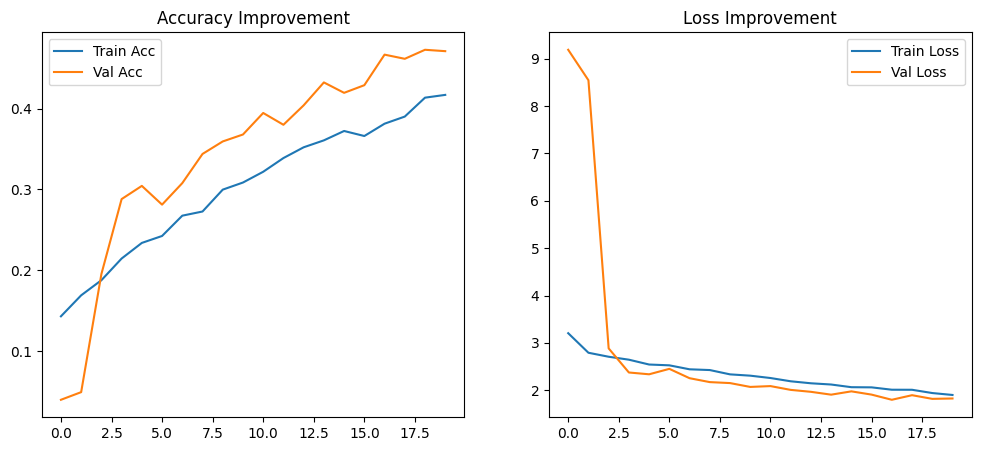

In [77]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.legend()
plt.title("Accuracy Improvement")
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title("Loss Improvement")
plt.show()